In [1]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from synthetic_generation.gan.models import Generator, Discriminator
from synthetic_generation.gan.process import GANProcess

In [2]:


def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Create distribution of disk-like clusters centered at the origin
    Parameters
    ----------
    n_samples : int
        number of data points to be created
    centers : int   
        number of clusters to have
    radius : float
        distance to origin of cluster centers
    std : float
        standard deviation of distance of points to cluster center
    seed : int
        random seed
    Returns
    -------
    tuple(np.ndarray)
        array of points, array of centers for each point, array of labels for each point
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [3]:

# Create data and labels and points
X, c_label, c_center = make_gaussian_mixture()

In [4]:
# one hot encode the labels
one_hot = torch.nn.functional.one_hot(torch.tensor(c_label), num_classes=8).float()

In [5]:
# combine the centers and labels into one conditional vector
c = torch.cat([torch.tensor(c_center), one_hot], dim=1)

In [6]:
# seed for reproducibility of weights
torch.manual_seed(42)

In [7]:
G = Generator(
    noise_dim = 2,
    num_hidden_layers = 2,
    out_dim = 2,
    hidden_dims=(128,128),
    conditional_dim=c.shape[1]
)

G_fm = copy.deepcopy(G)
G_fm_e = copy.deepcopy(G)

In [8]:
D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128),
    conditional_dim=c.shape[1]
)

D_fm = copy.deepcopy(D)
D_fm_e = copy.deepcopy(D)

In [9]:
# train conditional GAN with no regularization
# create a process
process = GANProcess(G=G, D=D)
torch.manual_seed(42) # seed again
process.train(
    X=torch.tensor(X),
    c=c
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [10]:
# train with just feature matching
torch.manual_seed(42) # seed again
process_fm = GANProcess(G=G_fm, D=D_fm)
process_fm.train(
    X=torch.tensor(X),
    c=c,
    lambda_fm_1=0.02,
    lambda_fm_2=0.02,
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [11]:
# train with feature matching and entropy
torch.manual_seed(42) # seed again
process_fm_e = GANProcess(G=G_fm_e, D=D_fm_e)
process_fm_e.train(
    X=torch.tensor(X),
    c=c,
    lambda_fm_1=0.02,
    lambda_fm_2=0.02,
    lambda_entropy=0.001,
)

GAN training:   0%|          | 0/200 [00:00<?, ?it/s]

In [14]:
c_label

array([6, 5, 5, ..., 1, 7, 1], shape=(50000,))

In [ ]:

@torch.no_grad()
def plot_samples(
    process: GANProcess,
    X_real: torch.Tensor | np.ndarray,
    c: torch.Tensor | None = None,
    c_label : np.ndarray | torch.Tensor = c_label,
    n:int =2000,
    title: str | None = None
    ):
    """
    plot fake and real points
    Parameters
    ----------
    process: GANProcess
        used to create fake points
    X_real: torch.Tensor | np.ndarray
        array of real data
    c : torch.Tensor | None
        if not none , the conditional to be used
    c_label : torch.Tensor | np.ndarray 
        labels used to color clusters
    n: int
        nmber of points to be generated
    title : str | None
        optional string to be used for title of plot
    """
    if c is not None:
        c_input = c[:n]
        c_label_plot = c_label[:n]
    else: 
        c_input = None
        c_label_plot = None
    X_fake = process.generate_samples(n, c_input).cpu().numpy()
    fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    axs[0].scatter(X_real[:n,0], X_real[:n,1], c=c_label_plot, alpha=0.3, cmap="tab10")
    axs[0].set_title("Real")
    axs[1].scatter(X_fake[:,0], X_fake[:,1], c=c_label_plot, alpha=0.3, cmap="tab10")
    axs[1].set_title("Generated")
    if title is not None:
        fig.suptitle(title)
    plt.show()

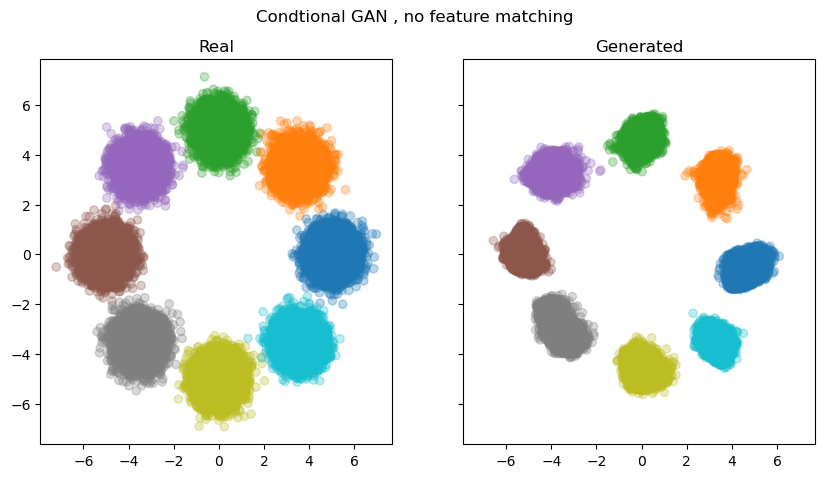

In [43]:
plot_samples(process, X, c, c_label, len(X), "Condtional GAN , no feature matching")

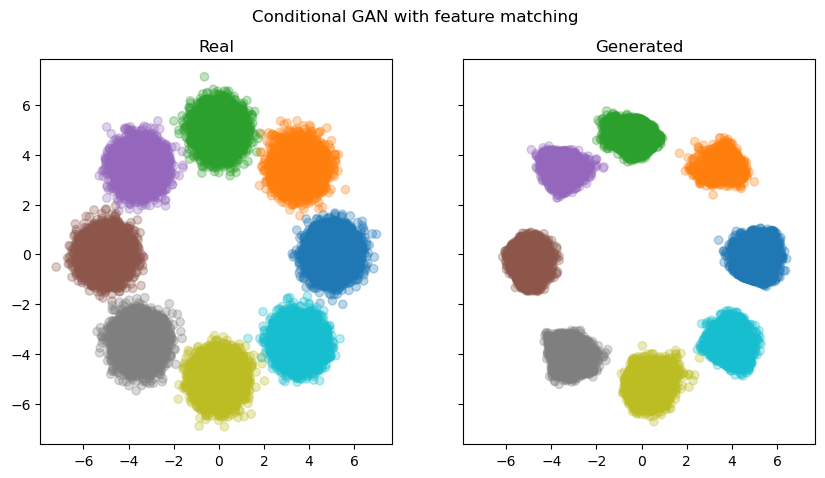

In [44]:
plot_samples(process_fm, X, c, c_label, len(X), "Conditional GAN with feature matching")

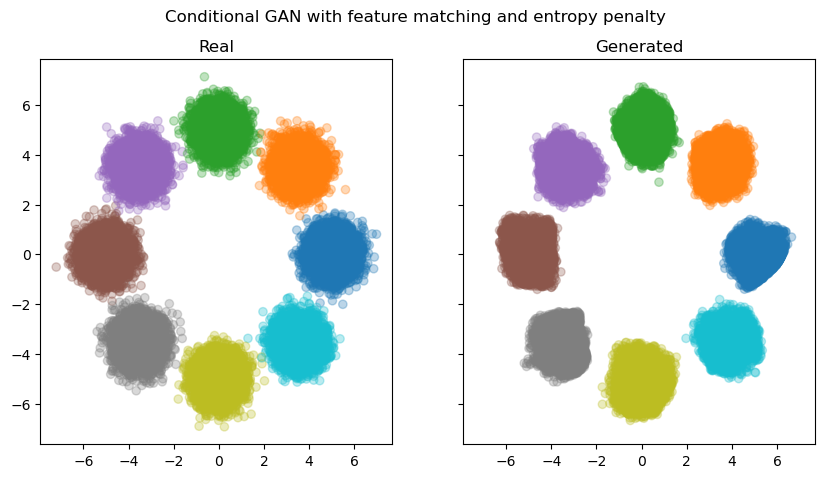

In [45]:
plot_samples(process_fm_e, X, c, c_label, len(X), "Conditional GAN with feature matching and entropy penalty")